# L5a Advanced: Rolling Correlations

The multiple asset GBM model of L5a has a constant covariance rate $\mathbf{C}$, just as the single asset model of L4b has a constant volatility. L4b showed that constant volatility fails a stylized fact (volatility clusters in time). This notebook asks the multi-asset version of the same question: is the __correlation__ between firms constant? We estimate correlations on rolling windows and with exponentially weighted moving averages through 2014 to 2024, for a few firm pairs and for the whole universe, and watch what happens in stressed markets. The answer shapes how a covariance estimate should be read: as a snapshot of a moving target, not a constant of nature.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Estimate correlations on rolling windows:** Compute the correlation of two firms' growth rates over a sliding window of trading days, see how the window length trades noise against responsiveness, and read the resulting time series.
> - **Use exponentially weighted estimates:** Compute the exponentially weighted covariance and correlation with a decay factor, explain the effective memory it implies, and compare it with the rolling-window estimate.
> - **Recognize correlation clustering:** Track the average pairwise correlation of the whole universe over time, show that it rises sharply when market volatility rises, and state what a constant covariance rate misses.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the course training dataset (2014 to 2024) and the growth-rate matrix of the L5a covariance example. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `VLQuantitativeFinancePackage.jl` package](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the dataset and growth-rate matrix, [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, the `Dates`, `LinearAlgebra`, `Statistics`, and `Random` standard libraries, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, and [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data
We use the daily data for the firms in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`. Let's load it with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep the firms with the maximum number of trading days, and build the growth-rate matrix $\mathbf{G}\in\mathbb{R}^{N\times M}$ with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). We also keep the trading dates so the time axes are calendar dates. We store the matrix in `G::Array{Float64,2}`, the tickers in `list_of_tickers::Array{String,1}`, and the dates in `dates::Vector{Date}`:

In [3]:
G, list_of_tickers, dates = let
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict(k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days);
    list_of_tickers = keys(dataset) |> collect |> sort;
    G = log_growth_matrix(dataset, list_of_tickers); # growth rates, N × M (row k is the growth over day k-1 -> k)
    dates = Date.(dataset["AAPL"][2:end, :timestamp]); # date of each growth-rate observation
    (G, list_of_tickers, dates)
end;
N, M = size(G)
Δt = 1/252;
println("N = $(N) growth-rate observations for M = $(M) firms, $(first(dates)) to $(last(dates))")

N = 2766 growth-rate observations for M = 424 firms, 2014-01-06 to 2024-12-31


___

## 1. Rolling-window correlations for a few pairs

The sample correlation of two firms over a window of $L$ trading days ending on day $k$ is the L5a correlation formula applied to rows $k-L+1,\dots,k$ of $\mathbf{G}$; sliding the window forward one day at a time gives a time series of correlations. A short window reacts quickly but is noisy (a 63-day correlation has a standard error of roughly $(1-\rho^{2})/\sqrt{63}\approx0.1$ near $\rho=0.5$); a long window is smooth but slow to notice a change. Let's implement the rolling correlation and compute it for three pairs with different relationships: two chip makers (AMD and NVDA), a bank and an oil major (JPM and XOM), and the S&P 500 fund against gold (SPY and GLD), for windows of 63 and 252 days:

In [4]:
function rolling_correlation(x::AbstractVector{<:Real}, y::AbstractVector{<:Real}, L::Int)
    n = length(x); ρ = fill(NaN, n)
    for k ∈ L:n
        xs = @view x[(k-L+1):k]; ys = @view y[(k-L+1):k]
        ρ[k] = cor(xs, ys)
    end
    return ρ
end

pairs = [("AMD", "NVDA"), ("JPM", "XOM"), ("SPY", "GLD")]
col(t) = findfirst(==(t), list_of_tickers)
rolling_df = let
    df = DataFrame(date = dates)
    for (a, b) ∈ pairs, L ∈ (63, 252)
        df[!, "$(a)-$(b) L=$(L)"] = rolling_correlation(G[:, col(a)], G[:, col(b)], L)
    end
    df
end;
full_sample = Dict("$(a)-$(b)" => cor(G[:, col(a)], G[:, col(b)]) for (a, b) ∈ pairs)

Dict{String, Float64} with 3 entries:
  "AMD-NVDA" => 0.58746
  "SPY-GLD"  => 0.0189938
  "JPM-XOM"  => 0.529183

The dictionary holds each pair's full-sample correlation, the single number the L5a covariance matrix would report. Let's plot the rolling estimates against it:

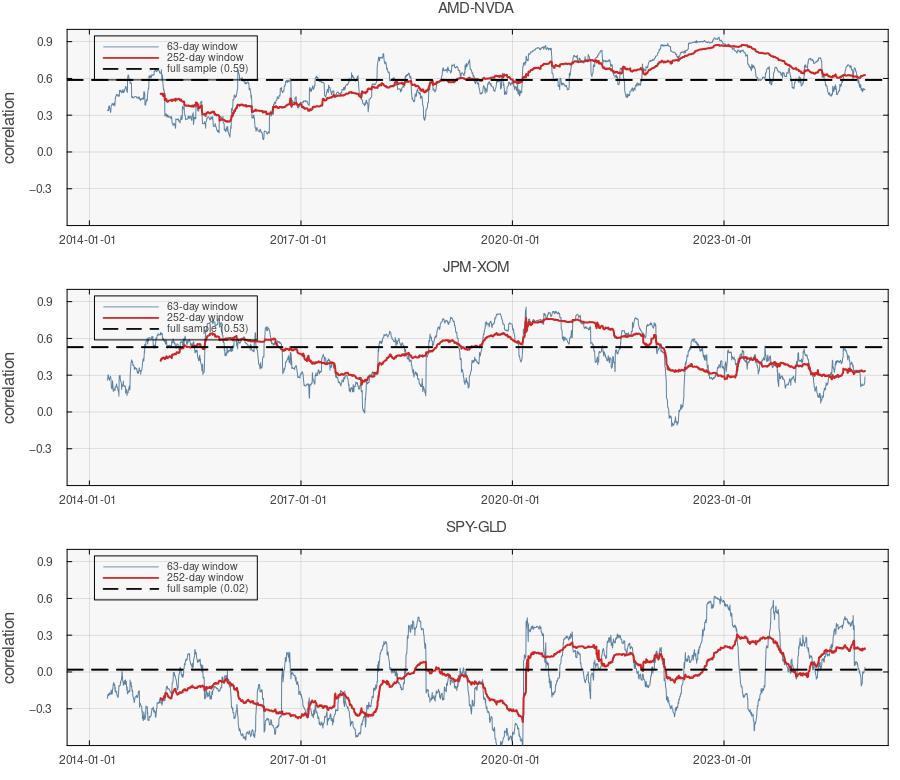

In [5]:
let
    panels = []
    for (a, b) ∈ pairs
        key = "$(a)-$(b)"
        p = plot(rolling_df.date, rolling_df[!, "$(key) L=63"]; color = :steelblue4, lw = 1, alpha = 0.8, label = "63-day window",
            ylabel = "correlation", title = key, titlefontsize = 10, ylims = (-0.6, 1.0))
        plot!(p, rolling_df.date, rolling_df[!, "$(key) L=252"]; color = :firebrick3, lw = 2, label = "252-day window")
        hline!(p, [full_sample[key]]; color = :black, linestyle = :dash, label = "full sample ($(round(full_sample[key], digits=2)))")
        push!(panels, p)
    end
    plot(panels...; layout = (3, 1), size = (900, 780), legend = :topleft, legendfontsize = 7)
end

Three different stories. The chip makers are strongly correlated on average, but their one-year correlation climbs from about 0.3 in 2015 to about 0.9 in 2023 before falling back; the full-sample 0.59 is true of no particular year. The bank and the oil major are moderately correlated on average (0.53), while their 63-day correlation swings from below zero to above 0.8. The index and gold sit near zero on average; the one-year correlation ranges from about minus 0.4 (2020) to plus 0.3, and the 63-day correlation swings more widely, from about minus 0.6 to plus 0.6. In every panel the full-sample number is a summary of a moving quantity, and around the 2020 stress period the estimates move sharply. Let's quantify that idea across the whole universe, but first a second estimator that does not use a hard window edge.

___

## 2. Exponentially weighted covariance and correlation

A rolling window gives every day inside it equal weight and every day outside it zero weight, so an outlier entering or leaving the window causes a jump. The __exponentially weighted moving average__ (EWMA) instead down-weights the past smoothly. With decay factor $\lambda\in(0,1)$, the EWMA variance and covariance update one day at a time:
$$
\hat{\Sigma}_{k}^{(ij)} = \lambda\,\hat{\Sigma}_{k-1}^{(ij)} + (1-\lambda)\,g^{(i)}_{k}\,g^{(j)}_{k},
$$
and the EWMA correlation is the usual ratio. As in the RiskMetrics convention, we do not subtract a mean: the daily mean growth rate is tiny compared with its standard deviation (about 0.1 versus 3 per year for a typical firm), and using a full-sample mean would smuggle future information into a past estimate. The decay time is about $1/(1-\lambda)$ days (the equivalent number of equally weighted observations is $(1+\lambda)/(1-\lambda)$): $\lambda=0.94$ corresponds to roughly seventeen days of decay time, and $\lambda=0.99$ to about one hundred. Let's implement the recursion for a pair, initializing on the first 63-day window, and compare it with the rolling estimates for AMD and NVDA:

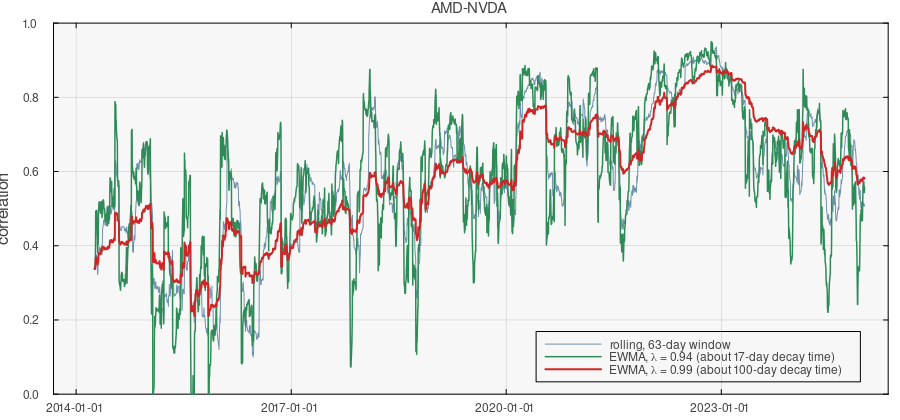

In [6]:
function ewma_correlation(x::AbstractVector{<:Real}, y::AbstractVector{<:Real}, λ::Real; burn_in::Int = 63)
    n = length(x)
    # initialize on the first window with uncentered second moments (zero-mean convention, no look-ahead)
    vx = mean(abs2, x[1:burn_in]); vy = mean(abs2, y[1:burn_in]); cxy = mean(x[1:burn_in] .* y[1:burn_in])
    ρ = fill(NaN, n); ρ[burn_in] = cxy/sqrt(vx*vy)
    for k ∈ (burn_in+1):n
        vx = λ*vx + (1 - λ)*x[k]^2
        vy = λ*vy + (1 - λ)*y[k]^2
        cxy = λ*cxy + (1 - λ)*x[k]*y[k]
        ρ[k] = cxy/sqrt(vx*vy)
    end
    return ρ
end

let
    x = G[:, col("AMD")]; y = G[:, col("NVDA")]
    p = plot(dates, rolling_df[!, "AMD-NVDA L=63"]; color = :steelblue4, lw = 1, alpha = 0.7, label = "rolling, 63-day window",
        ylabel = "correlation", title = "AMD-NVDA", titlefontsize = 10, ylims = (0.0, 1.0), size = (900, 420), legend = :bottomright)
    plot!(p, dates, ewma_correlation(x, y, 0.94); color = :seagreen4, lw = 1.5, label = "EWMA, λ = 0.94 (about 17-day decay time)")
    plot!(p, dates, ewma_correlation(x, y, 0.99); color = :firebrick3, lw = 2, label = "EWMA, λ = 0.99 (about 100-day decay time)")
    p
end

The EWMA with a short decay time tracks the 63-day rolling estimate closely but without the jumps when an extreme day drops out of the window; the long-decay EWMA is smoother still. Neither is right or wrong: the decay factor, like the window length, is a choice about how fast you believe correlations move, and it should be stated with the estimate.

___

## 3. Correlation clustering across the whole universe

Now the whole market. For each 63-day window (stepping forward one week at a time to keep the computation light) we compute the correlation matrix of a fixed random subset of one hundred firms and record the __average off-diagonal correlation__, together with the realized volatility of SPY over the same window. If correlations were constant, the average would wander only within its sampling noise; if they cluster, it will move with the market's stress. We store the series in the `universe_df::DataFrame` variable:

In [7]:
universe_df = let
    rng = MersenneTwister(5660)
    subset = sort(randperm(rng, M)[1:100]) # a fixed random subset of 100 firms
    L = 63; step = 5
    spy = G[:, col("SPY")]
    df = DataFrame(date = Date[], mean_correlation = Float64[], spy_volatility = Float64[])
    for k ∈ L:step:N
        W = G[(k-L+1):k, subset]
        R = cor(W, dims=1)
        mean_ρ = (sum(R) - 100)/(100*99)
        σ_spy = std(spy[(k-L+1):k])*sqrt(Δt) # annualized volatility of SPY over the window
        push!(df, (dates[k], mean_ρ, σ_spy))
    end
    df
end;
println("Average pairwise correlation over the decade: mean $(round(mean(universe_df.mean_correlation), digits=3)), min $(round(minimum(universe_df.mean_correlation), digits=3)), max $(round(maximum(universe_df.mean_correlation), digits=3))")

Average pairwise correlation over the decade: mean 0.282, min 0.065, max 0.605


Let's plot the average correlation and the SPY volatility on the same time axis:

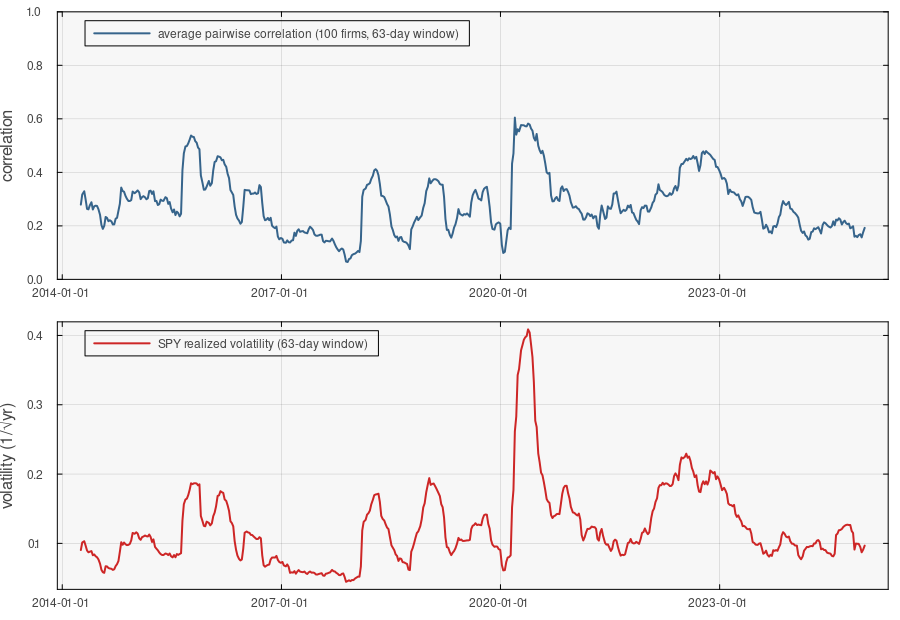

In [8]:
let
    p1 = plot(universe_df.date, universe_df.mean_correlation; color = :steelblue4, lw = 2, label = "average pairwise correlation (100 firms, 63-day window)",
        ylabel = "correlation", legend = :topleft, ylims = (0, 1))
    p2 = plot(universe_df.date, universe_df.spy_volatility; color = :firebrick3, lw = 2, label = "SPY realized volatility (63-day window)",
        ylabel = "volatility (1/√yr)", legend = :topleft)
    plot(p1, p2; layout = (2, 1), size = (900, 620), link = :x)
end

The average correlation is anything but constant: it sits between roughly 0.1 and 0.35 in calm stretches and jumps to about 0.5 in 2015 to 2016 and 2022 and to 0.6 in early 2020, and every one of those jumps coincides with a spike in market volatility. Correlations rise exactly when diversification is needed most, which is why a portfolio built on a calm-period covariance can lose more in a crisis than that covariance predicts. Let's put a number on the relationship, the correlation between the two series and how the average correlation differs between calm and stressed windows:

In [9]:
let
    ρ_series = cor(universe_df.mean_correlation, universe_df.spy_volatility)
    stressed = universe_df.spy_volatility .> quantile(universe_df.spy_volatility, 0.9)
    println("Correlation between average pairwise correlation and SPY volatility across windows: $(round(ρ_series, digits=3))")
    println("Average pairwise correlation in the calmest 90% of windows: $(round(mean(universe_df.mean_correlation[.!stressed]), digits=3)); in the 10% most volatile windows: $(round(mean(universe_df.mean_correlation[stressed]), digits=3))")
end

Correlation between average pairwise correlation and SPY volatility across windows: 0.861
Average pairwise correlation in the calmest 90% of windows: 0.261; in the 10% most volatile windows: 0.473


So the multi-asset model inherits the single-asset failure in a new form: constant volatility misses volatility clustering, and constant covariance misses __correlation clustering__. Nothing in this notebook says the covariance estimate is useless; the L5a estimate is a fair average description of a decade, and an average covariance is a reasonable summary of the second moments a long-horizon simulation integrates over, even though it cannot reproduce when the stress arrives or how volatility and correlation rise together in the tails. It does say that the estimate should carry its window and its estimator, and that anyone using it for risk in a stressed market should expect the true correlations to be higher than the average.

___

## Summary

This notebook estimated correlations through time instead of once, and found them moving: pairwise correlations wander by tens of points over a decade, and the average correlation of the whole market rises sharply whenever volatility does.

> __Key Takeaways:__
>
> - **Rolling windows expose the motion:** A sliding-window correlation shows that the full-sample number is a summary of a moving quantity, with the window length trading noise against responsiveness.
> - **Exponential weighting is the smoother alternative:** The EWMA covariance down-weights the past with a decay factor whose decay time is about one over one minus the decay, and it avoids the jumps of a hard window edge.
> - **Correlations cluster with volatility:** The average pairwise correlation across the market rises in stressed periods, exactly when diversification matters most, which is what a constant covariance rate cannot represent.

Time-varying covariance models are beyond this course; what stays with us is the reading rule for the covariance we do estimate: state its window, and expect it to understate correlation in a crisis.

___

## Disclaimer and Risks

This notebook is for instruction only. Correlation estimates depend on the window, the decay factor, and the sample; the stress episodes discussed are historical and need not repeat. This material is not investment or trading advice.

___